# **Step 0 - Setup, Imports, Seeds**
Reproducibility requires fixing the seed for every source of randomness: NumPy, Python's `random`, TensorFlow's global RNG, and the operation-level seed used by `image_dataset_from_directory`'s train/val split.

In [5]:
pip install tensorflow

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
import os
import time
import random
import pathlib
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.metrics import (
    precision_score, recall_score, f1_score, roc_auc_score,
    roc_curve, confusion_matrix, classification_report
)

SEED = 42

def set_seeds(seed: int = SEED) -> None:
    """Fix all relevant RNGs so runs are reproducible end-to-end."""
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

set_seeds(SEED)

IMG_SIZE = (128, 128)       # target size fixed by the lab spec
IMG_SHAPE = IMG_SIZE + (3,)
BATCH_SIZE = 32
VAL_SPLIT = 0.2

# Auto-detect dataset location. The project workspace includes a local
# `Dataset/` folder, which should be preferred for offline/local execution.
# Kaggle hosts mount the data under /kaggle/input/, and a Kaggle download is
# only used as a fallback when the local workspace dataset is absent.
_LOCAL_DATASET = pathlib.Path.cwd() / "Dataset"
_KAGGLE_INPUT = pathlib.Path("/kaggle/input/cats-and-dogs-image-classification")

if _KAGGLE_INPUT.exists():
    TRAIN_DIR = _KAGGLE_INPUT / "train"
    TEST_DIR = _KAGGLE_INPUT / "test"
elif _LOCAL_DATASET.exists():
    TRAIN_DIR = _LOCAL_DATASET / "train"
    TEST_DIR = _LOCAL_DATASET / "test"
else:
    try:
        import kagglehub
    except ModuleNotFoundError as exc:
        raise ModuleNotFoundError(
            "No local Dataset folder was found and kagglehub is not installed. "
            "Add the dataset to the workspace under Dataset/train and Dataset/test "
            "or install kagglehub."
        ) from exc
    _dataset_path = pathlib.Path(
        kagglehub.dataset_download("samuelcortinhas/cats-and-dogs-image-classification")
    )
    TRAIN_DIR = _dataset_path / "train"
    TEST_DIR = _dataset_path / "test"

for _p in (TRAIN_DIR, TEST_DIR):
    assert _p.exists(), f"Expected dataset directory not found: {_p}"

print("TRAIN_DIR:", TRAIN_DIR)
print("TEST_DIR:", TEST_DIR)

os.makedirs("models/checkpoints", exist_ok=True)
os.makedirs("models/final", exist_ok=True)
os.makedirs("reports/figures", exist_ok=True)
os.makedirs("reports/metrics", exist_ok=True)

print("TensorFlow:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices("GPU"))

TRAIN_DIR: e:\Ayusman SDP Lab 3\Dataset\train
TEST_DIR: e:\Ayusman SDP Lab 3\Dataset\test
TensorFlow: 2.21.0
GPU available: []


# **Step 1 - Dataset Exploration**
Before touching the model, verify the dataset is what the spec claims: count images per split/class, check class balance, inspect image dimensions (native size varies — this is *why* we resize in Section 3), confirm color mode, and flag any corrupted files so they don't crash training mid-epoch.

In [7]:
def scan_dataset(root_dir: pathlib.Path) -> dict:
    """Walk a train/ or test/ directory of {cats/, dogs/} subfolders and
    compute count, dimension, color-mode, and corruption statistics.

    Returns a dict with per-class counts, dimension stats, RGB-mode counts,
    and a list of corrupted file paths (unreadable or failing PIL verify()).
    """
    stats = {"per_class_count": {}, "widths": [], "heights": [],
              "modes": {}, "corrupted": []}

    for class_dir in sorted(p for p in root_dir.iterdir() if p.is_dir()):
        class_name = class_dir.name
        files = list(class_dir.glob("*"))
        valid_count = 0

        for f in files:
            try:
                with Image.open(f) as img:
                    img.verify()  # cheap structural check, doesn't decode pixels
                # re-open after verify() (verify() invalidates the file handle)
                with Image.open(f) as img:
                    w, h = img.size
                    stats["widths"].append(w)
                    stats["heights"].append(h)
                    stats["modes"][img.mode] = stats["modes"].get(img.mode, 0) + 1
                valid_count += 1
            except Exception as e:
                stats["corrupted"].append((str(f), str(e)))

        stats["per_class_count"][class_name] = valid_count

    stats["total_valid"] = sum(stats["per_class_count"].values())
    stats["total_corrupted"] = len(stats["corrupted"])
    return stats


def summarize(stats: dict, split_name: str) -> None:
    """Pretty-print scan_dataset() output."""
    print(f"--- {split_name} ---")
    print("Per-class counts:", stats["per_class_count"])
    total = stats["total_valid"]
    for cls, cnt in stats["per_class_count"].items():
        print(f"  {cls}: {cnt} ({cnt/total:.1%} of split)")
    if stats["widths"]:
        print(f"Width  -> min {min(stats['widths'])}, max {max(stats['widths'])}, "
              f"avg {np.mean(stats['widths']):.1f}")
        print(f"Height -> min {min(stats['heights'])}, max {max(stats['heights'])}, "
              f"avg {np.mean(stats['heights']):.1f}")
    print("Color modes:", stats["modes"])
    print(f"Corrupted files: {stats['total_corrupted']}")
    if stats["corrupted"]:
        for path, err in stats["corrupted"][:5]:
            print("   ", path, "->", err)
    print()


train_stats = scan_dataset(TRAIN_DIR)
test_stats = scan_dataset(TEST_DIR)
summarize(train_stats, "TRAIN")
summarize(test_stats, "TEST")

# Class-balance flag: used later to decide whether class_weight is needed
class_counts = train_stats["per_class_count"]
imbalance_ratio = max(class_counts.values()) / min(class_counts.values())
print(f"Train class imbalance ratio: {imbalance_ratio:.2f} "
      f"({'balanced' if imbalance_ratio < 1.2 else 'imbalanced -> consider class_weight'})")

--- TRAIN ---
Per-class counts: {'cats': 279, 'dogs': 278}
  cats: 279 (50.1% of split)
  dogs: 278 (49.9% of split)
Width  -> min 133, max 4272, avg 952.5
Height -> min 133, max 4272, avg 657.2
Color modes: {'RGB': 556, 'L': 1}
Corrupted files: 0

--- TEST ---
Per-class counts: {'cats': 70, 'dogs': 70}
  cats: 70 (50.0% of split)
  dogs: 70 (50.0% of split)
Width  -> min 191, max 4735, avg 886.7
Height -> min 158, max 3157, avg 612.1
Color modes: {'RGB': 140}
Corrupted files: 0

Train class imbalance ratio: 1.00 (balanced)


# **Step 2 - Visual Exploration**
A 4x3 grid of random images sampled across both classes, each subplot titled with its class and native (pre-resize) dimensions — a quick sanity check that labels and images line up, and that dimension variability is real (justifying the fixed resize in Section 3).

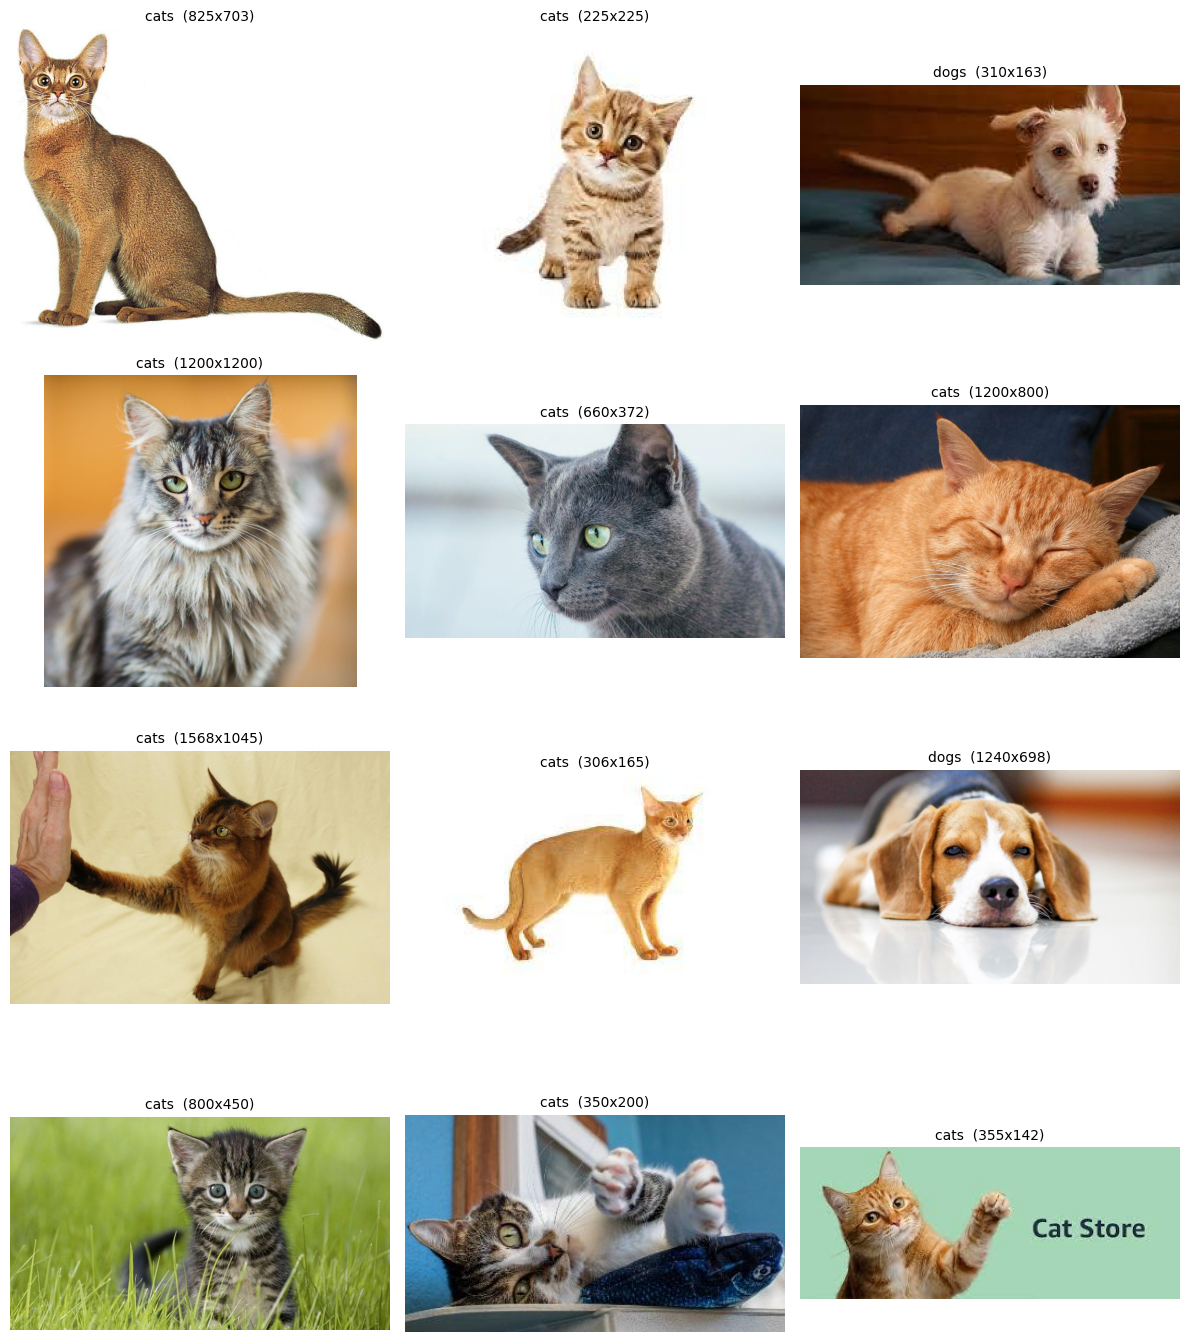

In [8]:
def plot_random_grid(root_dir: pathlib.Path, n_rows: int = 4, n_cols: int = 3,
                       seed: int = SEED) -> None:
    """Display an n_rows x n_cols grid of randomly sampled images with
    class + native-dimension titles."""
    rng = random.Random(seed)
    class_dirs = sorted(p for p in root_dir.iterdir() if p.is_dir())
    all_files = []
    for class_dir in class_dirs:
        for f in class_dir.glob("*"):
            all_files.append((f, class_dir.name))

    sample = rng.sample(all_files, n_rows * n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 14))
    for ax, (path, label) in zip(axes.flat, sample):
        with Image.open(path) as img:
            w, h = img.size
            ax.imshow(img.convert("RGB"))
        ax.set_title(f"{label}  ({w}x{h})", fontsize=10)
        ax.axis("off")
    plt.tight_layout()
    plt.savefig("reports/figures/eda_sample_grid.png", dpi=120)
    plt.show()

plot_random_grid(TRAIN_DIR)

# **Step 3 - Preprocessing**
**Why resize to 128x128:** CNN backbones require a fixed input shape; 128x128 keeps memory/compute low while retaining enough detail for a binary cat/dog decision — Section 1 showed native sizes vary widely, so a fixed target is mandatory, not optional.

**Why force RGB:** `image_dataset_from_directory(color_mode='rgb')` guarantees 3 channels even if a source file is grayscale/CMYK/RGBA, so every backbone (all pretrained on 3-channel ImageNet) receives a consistent input shape.

**Why normalize, and why per-backbone:** pixel values start in [0, 255]. Each pretrained backbone was trained with its *own* normalization convention (VGG16/ResNet50 use ImageNet mean-subtraction in BGR order; MobileNetV2/Xception/EfficientNetB0 scale to [-1, 1]). Using the wrong convention silently degrades transfer-learning accuracy, so normalization is applied via each backbone's own `preprocess_input`, inside the model itself (Section 5) — not baked into the shared `tf.data` pipeline.

**Train/val split:** built only from `train/`, via `image_dataset_from_directory`'s `validation_split`; `test/` is loaded separately and never seen until Section 9.

### Pixel Normalization

The original image pixels are represented in the range [0, 255].

For the baseline CNN, pixel values are normalized to the range [0, 1]
using:

    x_normalized = x / 255.0

This normalization helps neural network training by keeping input
values within a smaller and consistent numerical range, which can
improve optimization and training stability.

For the transfer-learning models, the input images are passed through
the preprocessing function associated with each ImageNet-pretrained
architecture. These architecture-specific preprocessing functions are
used to maintain compatibility with the pretrained ImageNet weights.

Therefore:

- Baseline CNN → [0,255] is scaled to [0,1]
- Transfer-learning models → architecture-specific ImageNet preprocessing

In [9]:
def build_datasets(train_dir: pathlib.Path, test_dir: pathlib.Path,
                     img_size=IMG_SIZE, batch_size=BATCH_SIZE,
                     val_split=VAL_SPLIT, seed=SEED):
    """Build train/val/test tf.data.Dataset objects.

    - train/val come from `train_dir` via a fixed validation_split.
    - test comes from `test_dir`, loaded once, untouched until final eval.
    - Images are resized to `img_size` and forced to RGB at load time.
    - Pixel-level normalization is intentionally NOT applied here (see
      Section 3 markdown) — it happens inside each model via preprocess_input.
    """
    train_ds = tf.keras.utils.image_dataset_from_directory(
        train_dir, validation_split=val_split, subset="training", seed=seed,
        image_size=img_size, batch_size=batch_size, color_mode="rgb",
        label_mode="binary",
    )
    val_ds = tf.keras.utils.image_dataset_from_directory(
        train_dir, validation_split=val_split, subset="validation", seed=seed,
        image_size=img_size, batch_size=batch_size, color_mode="rgb",
        label_mode="binary",
    )
    test_ds = tf.keras.utils.image_dataset_from_directory(
        test_dir, image_size=img_size, batch_size=batch_size,
        color_mode="rgb", label_mode="binary", shuffle=False,
    )

    class_names = train_ds.class_names  # alphabetical -> ['cats', 'dogs']
    assert class_names == ["cats", "dogs"], (
        f"Unexpected class order {class_names}; Cat must encode to 0, Dog to 1."
    )

    AUTOTUNE = tf.data.AUTOTUNE
    train_ds = train_ds.cache().prefetch(AUTOTUNE)
    val_ds = val_ds.cache().prefetch(AUTOTUNE)
    test_ds = test_ds.cache().prefetch(AUTOTUNE)

    return train_ds, val_ds, test_ds, class_names


train_ds, val_ds, test_ds, CLASS_NAMES = build_datasets(TRAIN_DIR, TEST_DIR)
print("Class encoding:", {i: name for i, name in enumerate(CLASS_NAMES)})
print("Train batches:", tf.data.experimental.cardinality(train_ds).numpy())
print("Val batches:  ", tf.data.experimental.cardinality(val_ds).numpy())
print("Test batches: ", tf.data.experimental.cardinality(test_ds).numpy())

Found 557 files belonging to 2 classes.
Using 446 files for training.
Found 557 files belonging to 2 classes.
Using 111 files for validation.
Found 140 files belonging to 2 classes.
Class encoding: {0: 'cats', 1: 'dogs'}
Train batches: 14
Val batches:   4
Test batches:  5


In [10]:
# Verify pixel normalization used by the baseline CNN

sample_images, sample_labels = next(iter(train_ds))

print("Original batch shape:", sample_images.shape)
print("Pixel minimum:", float(tf.reduce_min(sample_images)))
print("Pixel maximum:", float(tf.reduce_max(sample_images)))

normalized_sample = sample_images / 255.0

print("\nAfter normalization:")
print("Minimum:", float(tf.reduce_min(normalized_sample)))
print("Maximum:", float(tf.reduce_max(normalized_sample)))

Original batch shape: (32, 128, 128, 3)
Pixel minimum: 0.0
Pixel maximum: 255.0

After normalization:
Minimum: 0.0
Maximum: 1.0


# **Step 4 - Augmentation**
**Why augment only the training data:** augmentation manufactures label-preserving variation (rotated/flipped/zoomed/shifted cats are still cats) so the model generalizes past the exact 697 images it has seen; applying it to val/test would corrupt the evaluation signal by measuring performance on distorted inputs the model was never meant to be graded on.

Implemented as `tf.keras.layers`, placed inside the model graph immediately after `Input` (Section 5) — these layers are no-ops automatically whenever `training=False` (i.e., during `evaluate`/`predict`), so val/test data is never touched by them even though they live inside the same model object.

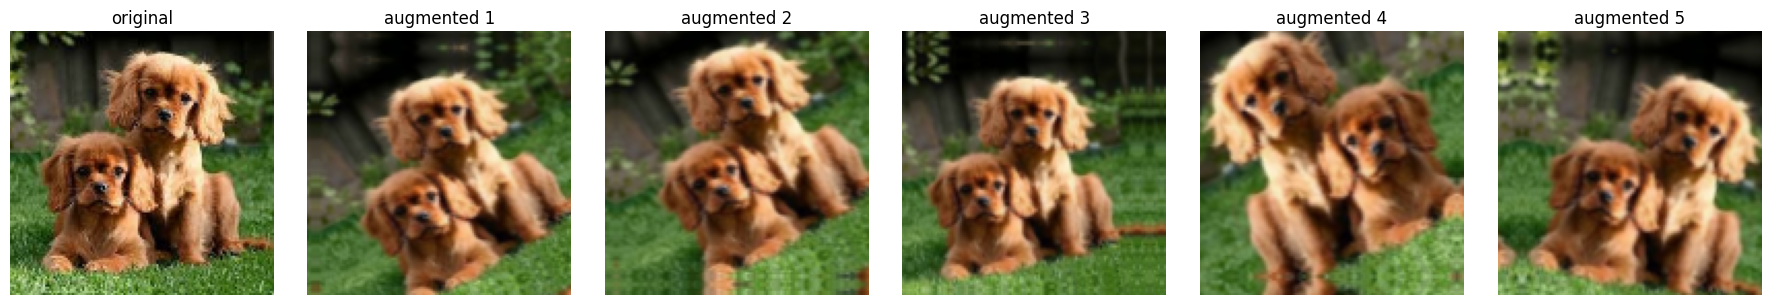

In [11]:
def build_augmentation() -> keras.Sequential:
    """Training-only augmentation block: horizontal flip, rotation, zoom,
    translation. Ranges are deliberately mild -- large enough to add useful
    variation for a ~700-image dataset without producing unrealistic cats/dogs."""
    return keras.Sequential([
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.08),                       # ~= +/-29 degrees
        layers.RandomZoom(height_factor=(-0.15, 0.15), width_factor=(-0.15, 0.15)),
        layers.RandomTranslation(height_factor=(-0.1, 0.1), width_factor=(-0.1, 0.1)),
    ], name="augmentation")


def visualize_augmentation(dataset: tf.data.Dataset, augmenter: keras.Sequential,
                             n_variants: int = 5) -> None:
    """Show 1 original image + n_variants augmented copies in a single row."""
    images, _ = next(iter(dataset.take(1)))
    original = images[0:1]  # keep batch dim for the augmenter

    fig, axes = plt.subplots(1, n_variants + 1, figsize=(3 * (n_variants + 1), 3))
    axes[0].imshow(original[0].numpy().astype("uint8"))
    axes[0].set_title("original")
    axes[0].axis("off")

    for i in range(n_variants):
        augmented = augmenter(original, training=True)  # force training-mode behavior
        axes[i + 1].imshow(tf.clip_by_value(augmented[0], 0, 255).numpy().astype("uint8"))
        axes[i + 1].set_title(f"augmented {i+1}")
        axes[i + 1].axis("off")

    plt.tight_layout()
    plt.savefig("reports/figures/augmentation_examples.png", dpi=120)
    plt.show()


augmenter = build_augmentation()
visualize_augmentation(train_ds, augmenter)

# Step 5 - Baseline CNN Model

Before applying transfer learning, a simple CNN is trained from scratch
to establish a baseline for comparison with the pretrained architectures.

In [12]:
# ============================================================
# Step 5 - Baseline CNN Model
# ============================================================

baseline_model = keras.Sequential([
    keras.Input(shape=IMG_SHAPE),

    # Normalize pixels from [0, 255] to [0, 1]
    layers.Rescaling(1.0 / 255),

    # Convolution Block 1
    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    # Convolution Block 2
    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    # Convolution Block 3
    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    # Classification Head
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),

    # Binary output: Cat = 0, Dog = 1
    layers.Dense(1, activation="sigmoid")
], name="Baseline_CNN")


baseline_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        keras.metrics.AUC(name="auc")
    ]
)

baseline_model.summary()

Model: "Baseline_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,889 (429.25 KB)

 Trainable params: 109,889 (429.25 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
# ============================================================
# Shared Training Callbacks
# ============================================================

def get_callbacks(checkpoint_path: str, patience: int = 5) -> list:
    """Standard callback stack reused by every training run."""
    return [
        keras.callbacks.EarlyStopping(
            monitor="val_loss", patience=patience, restore_best_weights=True
        ),
        keras.callbacks.ModelCheckpoint(
            checkpoint_path, monitor="val_loss", save_best_only=True
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss", factor=0.5, patience=3, min_lr=1e-7
        ),
    ]

# ============================================================
# Shared Evaluation Helpers
# ============================================================

def evaluate_on_test(model: keras.Model, test_ds: tf.data.Dataset) -> dict:
    """Run inference on the full test set once; return y_true, predicted
    probabilities, and standard classification metrics."""
    y_true, y_prob = [], []
    for images, labels in test_ds:
        probs = model.predict(images, verbose=0).ravel()
        y_true.extend(labels.numpy().ravel().tolist())
        y_prob.extend(probs.tolist())

    y_true = np.array(y_true)
    y_prob = np.array(y_prob)
    y_pred = (y_prob > 0.5).astype(int)

    return {
        "y_true": y_true, "y_prob": y_prob, "y_pred": y_pred,
        "accuracy": float(np.mean(y_true == y_pred)),
        "precision": precision_score(y_true, y_pred),
        "recall": recall_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred),
        "auc": roc_auc_score(y_true, y_prob),
    }


def count_params(model: keras.Model) -> tuple:
    """Return (total_params, trainable_params) for a compiled model."""
    total = model.count_params()
    trainable = int(sum(np.prod(v.shape) for v in model.trainable_weights))
    return total, trainable


def measure_inference_time(model: keras.Model, sample_batch, n_runs: int = 20) -> float:
    """Average single-image inference latency in milliseconds."""
    single = sample_batch[0:1]
    model.predict(single, verbose=0)  # warm up
    start = time.time()
    for _ in range(n_runs):
        model.predict(single, verbose=0)
    return (time.time() - start) / n_runs * 1000

# ============================================================
# Train Baseline CNN
# ============================================================

BASELINE_EPOCHS = 15

baseline_checkpoint = "models/checkpoints/baseline_cnn.keras"

start = time.time()

baseline_history = baseline_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=BASELINE_EPOCHS,
    callbacks=get_callbacks(baseline_checkpoint),
    verbose=1
)

baseline_training_time = time.time() - start

print(f"\nBaseline CNN training time: {baseline_training_time:.1f} seconds")

Epoch 1/15


C:\Users\ayusm\AppData\Roaming\Python\Python313\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


14/14 ━━━━━━━━━━━━━━━━━━━━ 7s 268ms/step - accuracy: 0.4731 - auc: 0.4758 - loss: 0.7002 - val_accuracy: 0.4955 - val_auc: 0.5435 - val_loss: 0.6933 - learning_rate: 0.0010
Epoch 2/15
14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 198ms/step - accuracy: 0.5359 - auc: 0.5123 - loss: 0.6931 - val_accuracy: 0.6036 - val_auc: 0.6594 - val_loss: 0.6904 - learning_rate: 0.0010
Epoch 3/15
14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 198ms/step - accuracy: 0.5269 - auc: 0.5290 - loss: 0.6922 - val_accuracy: 0.6216 - val_auc: 0.6649 - val_loss: 0.6881 - learning_rate: 0.0010
Epoch 4/15
14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 198ms/step - accuracy: 0.5179 - auc: 0.5542 - loss: 0.6893 - val_accuracy: 0.6126 - val_auc: 0.6564 - val_loss: 0.6823 - learning_rate: 0.0010
Epoch 5/15
14/14 ━━━━━━━━━━━━━━━━━━━━ 5s 196ms/step - accuracy: 0.5471 - auc: 0.5768 - loss: 0.6876 - val_accuracy: 0.5766 - val_auc: 0.5958 - val_loss: 0.6844 - learning_rate: 0.0010
Epoch 6/15
14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 196ms/step - accuracy: 0.5605 - auc: 0.5654 - loss

In [14]:
# ============================================================
# Evaluate Baseline CNN on Test Set
# ============================================================

baseline_result = evaluate_on_test(
    baseline_model,
    test_ds
)

baseline_total_params, baseline_trainable_params = count_params(
    baseline_model
)

print("Baseline CNN Results")
print("-" * 40)
print(f"Test Accuracy : {baseline_result['accuracy']:.4f}")
print(f"Precision     : {baseline_result['precision']:.4f}")
print(f"Recall        : {baseline_result['recall']:.4f}")
print(f"F1 Score      : {baseline_result['f1']:.4f}")
print(f"AUC           : {baseline_result['auc']:.4f}")
print(f"Parameters    : {baseline_total_params:,}")
print(f"Trainable     : {baseline_trainable_params:,}")
print(f"Training Time : {baseline_training_time:.1f} sec")

Baseline CNN Results
----------------------------------------
Test Accuracy : 0.6214
Precision     : 0.6441
Recall        : 0.5429
F1 Score      : 0.5891
AUC           : 0.6335
Parameters    : 109,889
Trainable     : 109,889
Training Time : 47.5 sec


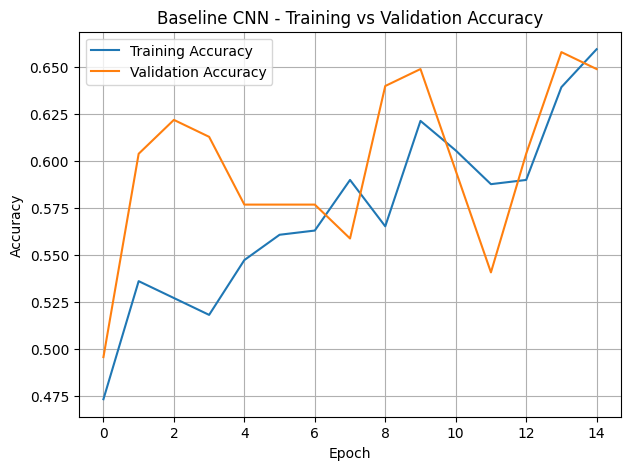

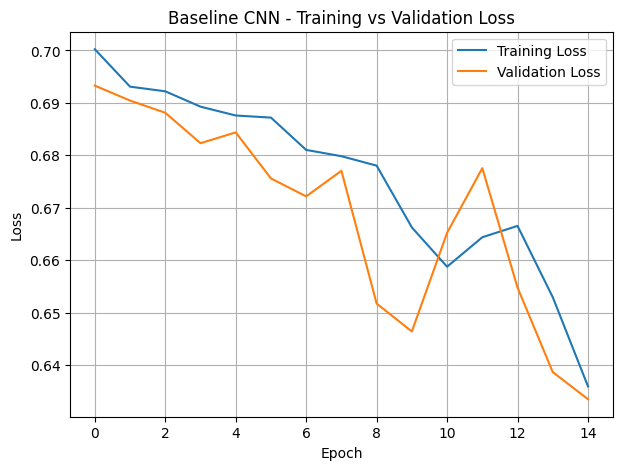

In [15]:
# ============================================================
# Baseline CNN Training Curves
# ============================================================

history = baseline_history.history

plt.figure(figsize=(7, 5))
plt.plot(history["accuracy"], label="Training Accuracy")
plt.plot(history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Baseline CNN - Training vs Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(7, 5))
plt.plot(history["loss"], label="Training Loss")
plt.plot(history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Baseline CNN - Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

# **Step 5 - Transfer-Learning Models (5 Backbones)**
A **factory pattern** builds any of the 5 backbones with an identical head, so there is exactly one code path shared across all models — no per-model copy-paste. Each entry in `MODEL_REGISTRY` pairs the `keras.applications` class with its matching `preprocess_input`, since (Section 3) each backbone expects different input normalization.

In [16]:
from tensorflow.keras.applications import (
    vgg16, resnet50, mobilenet_v2, efficientnet, xception
)

MODEL_REGISTRY = {
    "VGG16": {
        "app": vgg16.VGG16,
        "preprocess": vgg16.preprocess_input,
        "default_unfreeze_n": 4,   # last conv block
    },
    "ResNet50": {
        "app": resnet50.ResNet50,
        "preprocess": resnet50.preprocess_input,
        "default_unfreeze_n": 10,  # last residual stage, block-aligned
    },
    "MobileNetV2": {
        "app": mobilenet_v2.MobileNetV2,
        "preprocess": mobilenet_v2.preprocess_input,
        "default_unfreeze_n": 20,  # last few inverted-residual blocks
    },
    "EfficientNetB0": {
        "app": efficientnet.EfficientNetB0,
        "preprocess": efficientnet.preprocess_input,
        "default_unfreeze_n": 15,
    },
    "Xception": {
        "app": xception.Xception,
        "preprocess": xception.preprocess_input,
        "default_unfreeze_n": 10,
    },
}


def build_model(backbone_name: str, dense_units: int = 128,
                 dropout: float = 0.3, img_shape=IMG_SHAPE) -> tuple:
    """Factory: build (model, base_model) for the given registered backbone.

    Common head for every backbone (per spec):
        GlobalAveragePooling2D -> Dense(relu) -> Dropout -> Dense(1, sigmoid)

    Augmentation + backbone-specific preprocessing live inside the graph, so
    they are automatically skipped at inference/eval time (training=False).
    The base is returned frozen; fine_tune() (Section 6) unfreezes it later.
    """
    cfg = MODEL_REGISTRY[backbone_name]
    base = cfg["app"](include_top=False, weights="imagenet", input_shape=img_shape)
    base.trainable = False  # Stage 1: frozen feature extractor

    inputs = keras.Input(shape=img_shape)
    x = build_augmentation()(inputs)                       # train-only, auto no-op at eval
    x = layers.Lambda(cfg["preprocess"], name="backbone_preprocess")(x)
    x = base(x, training=False)                              # keep BN stats frozen
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(dense_units, activation="relu")(x)
    x = layers.Dropout(dropout)(x)
    outputs = layers.Dense(1, activation="sigmoid")(x)

    model = keras.Model(inputs, outputs, name=f"{backbone_name}_head")
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="binary_crossentropy",
        metrics=["accuracy", keras.metrics.AUC(name="auc")],
    )
    return model, base


def get_callbacks(checkpoint_path: str, patience: int = 5) -> list:
    """Standard callback stack reused by every training run."""
    return [
        keras.callbacks.EarlyStopping(
            monitor="val_loss", patience=patience, restore_best_weights=True
        ),
        keras.callbacks.ModelCheckpoint(
            checkpoint_path, monitor="val_loss", save_best_only=True
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss", factor=0.5, patience=3, min_lr=1e-7
        ),
    ]

# **Step 5.1 - Stage 1 — Train All 5 Backbones (Frozen Base)**
Looping over `MODEL_REGISTRY` (not copy-pasting per model) trains all five with identical settings, storing each model, its base reference, and its `History` for later comparison and fine-tuning.

In [17]:
EPOCHS_STAGE1 = 15
trained_models = {}     # name -> {"model", "base", "history1"}

for name in MODEL_REGISTRY:
    print(f"\n=== Stage 1: {name} ===")
    set_seeds(SEED)  # re-fix seeds so every backbone starts from the same RNG state
    model, base = build_model(name)
    ckpt_path = f"models/checkpoints/{name}_stage1.keras"

    start = time.time()
    history1 = model.fit(
        train_ds, validation_data=val_ds, epochs=EPOCHS_STAGE1,
        callbacks=get_callbacks(ckpt_path), verbose=1,
    )
    elapsed = time.time() - start

    trained_models[name] = {
        "model": model, "base": base, "history1": history1,
        "stage1_time_sec": elapsed,
    }
    print(f"{name} Stage 1 done in {elapsed:.1f}s "
          f"(best val_loss epoch: {np.argmin(history1.history['val_loss']) + 1})")


=== Stage 1: VGG16 ===

Epoch 1/15


C:\Users\ayusm\AppData\Roaming\Python\Python313\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


14/14 ━━━━━━━━━━━━━━━━━━━━ 28s 2s/step - accuracy: 0.6771 - auc: 0.7287 - loss: 2.4498 - val_accuracy: 0.8288 - val_auc: 0.9233 - val_loss: 0.8323 - learning_rate: 0.0010
Epoch 2/15
14/14 ━━━━━━━━━━━━━━━━━━━━ 24s 2s/step - accuracy: 0.8251 - auc: 0.8872 - loss: 0.9290 - val_accuracy: 0.8919 - val_auc: 0.9519 - val_loss: 0.3546 - learning_rate: 0.0010
Epoch 3/15
14/14 ━━━━━━━━━━━━━━━━━━━━ 25s 2s/step - accuracy: 0.8812 - auc: 0.9380 - loss: 0.5227 - val_accuracy: 0.8919 - val_auc: 0.9600 - val_loss: 0.3253 - learning_rate: 0.0010
Epoch 4/15
14/14 ━━━━━━━━━━━━━━━━━━━━ 24s 2s/step - accuracy: 0.8901 - auc: 0.9433 - loss: 0.4459 - val_accuracy: 0.8919 - val_auc: 0.9662 - val_loss: 0.3426 - learning_rate: 0.0010
Epoch 5/15
14/14 ━━━━━━━━━━━━━━━━━━━━ 25s 2s/step - accuracy: 0.8991 - auc: 0.9667 - loss: 0.2955 - val_accuracy: 0.9099 - val_auc: 0.9628 - val_loss: 0.2894 - learning_rate: 0.0010
Epoch 6/15
14/14 ━━━━━━━━━━━━━━━━━━━━ 25s 2s/step - accuracy: 0.9260 - auc: 0.9687 - loss: 0.2521 - v

# **Feature Extraction Results**

In the first stage of transfer learning, the convolutional base of each
pre-trained ImageNet model is kept frozen and only the newly added
classification head is trained.

The validation performance obtained during this feature-extraction stage
is recorded below. These results will later be compared with the
fine-tuned models to determine whether unfreezing deeper layers improves
performance.

In [18]:
# ============================================================
# Feature Extraction Results
# ============================================================

feature_extraction_results = []

for name, entry in trained_models.items():

    history1 = entry["history1"].history

    best_val_accuracy = max(history1["val_accuracy"])
    best_val_loss = min(history1["val_loss"])

    feature_extraction_results.append({
        "Model": name,
        "Best Validation Accuracy": best_val_accuracy,
        "Best Validation Loss": best_val_loss
    })

feature_extraction_df = pd.DataFrame(feature_extraction_results)

feature_extraction_df = feature_extraction_df.sort_values(
    "Best Validation Accuracy",
    ascending=False
).reset_index(drop=True)

feature_extraction_df

,Model,Best Validation Accuracy,Best Validation Loss
0,MobileNetV2,0.981982,0.106257
1,EfficientNetB0,0.945946,0.130220
2,ResNet50,0.945946,0.189700
3,VGG16,0.918919,0.253469
4,Xception,0.900901,0.222353


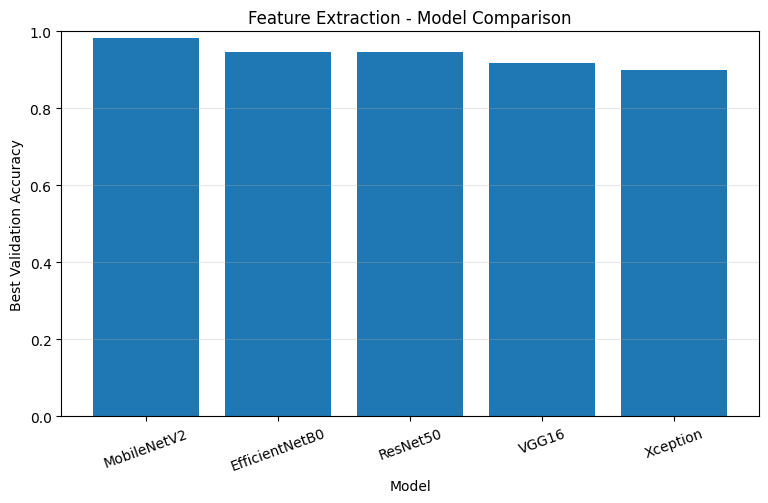

In [19]:
# ============================================================
# Feature Extraction - Validation Accuracy Comparison
# ============================================================

plt.figure(figsize=(9, 5))

plt.bar(
    feature_extraction_df["Model"],
    feature_extraction_df["Best Validation Accuracy"]
)

plt.xlabel("Model")
plt.ylabel("Best Validation Accuracy")
plt.title("Feature Extraction - Model Comparison")
plt.ylim(0, 1)

plt.xticks(rotation=20)
plt.grid(axis="y", alpha=0.3)

plt.show()

### Observation

The feature-extraction results show the performance of the five
pre-trained CNN architectures when their convolutional bases remain
frozen.

These results provide the baseline for evaluating the effect of
fine-tuning. An improvement after fine-tuning would indicate that
allowing selected deeper layers to adapt to the Cat vs Dog dataset
provides additional task-specific learning.

# **Step 6 - Fine-Tuning**
A single reusable function unfreezes the last **N** layers of a given base model (BatchNorm layers stay frozen regardless, to protect their running statistics on a small dataset), recompiles with a low learning rate so pretrained weights are nudged rather than destroyed, and continues training.

In [20]:
def unfreeze_top_n_layers(base_model: keras.Model, n: int) -> None:
    """Unfreeze the last n layers of base_model; keep BatchNorm frozen and
    keep every earlier layer frozen. Reusable across all 5 backbones."""
    base_model.trainable = True
    freeze_until = len(base_model.layers) - n
    for i, layer in enumerate(base_model.layers):
        if i < freeze_until or isinstance(layer, layers.BatchNormalization):
            layer.trainable = False
        else:
            layer.trainable = True


def fine_tune(model: keras.Model, base_model: keras.Model, n: int,
               train_ds, val_ds, checkpoint_path: str,
               lr: float = 1e-5, epochs: int = 10) -> keras.callbacks.History:
    """Stage 2: unfreeze last n layers of base_model, recompile with a small
    LR, and continue training. Returns the new History object."""
    unfreeze_top_n_layers(base_model, n)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss="binary_crossentropy",
        metrics=["accuracy", keras.metrics.AUC(name="auc")],
    )
    history = model.fit(
        train_ds, validation_data=val_ds, epochs=epochs,
        callbacks=get_callbacks(checkpoint_path), verbose=1,
    )
    return history


EPOCHS_STAGE2 = 10

for name, cfg in MODEL_REGISTRY.items():
    print(f"\n=== Stage 2 (fine-tune): {name} ===")
    entry = trained_models[name]
    ckpt_path = f"models/checkpoints/{name}_stage2.keras"

    start = time.time()
    history2 = fine_tune(
        entry["model"], entry["base"], n=cfg["default_unfreeze_n"],
        train_ds=train_ds, val_ds=val_ds, checkpoint_path=ckpt_path,
        lr=1e-5, epochs=EPOCHS_STAGE2,
    )
    elapsed = time.time() - start

    entry["history2"] = history2
    entry["stage2_time_sec"] = elapsed
    entry["total_time_sec"] = entry["stage1_time_sec"] + elapsed
    print(f"{name} Stage 2 done in {elapsed:.1f}s")


=== Stage 2 (fine-tune): VGG16 ===
Epoch 1/10


C:\Users\ayusm\AppData\Roaming\Python\Python313\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


14/14 ━━━━━━━━━━━━━━━━━━━━ 55s 3s/step - accuracy: 0.9484 - auc: 0.9909 - loss: 0.1298 - val_accuracy: 0.8919 - val_auc: 0.9628 - val_loss: 0.3030 - learning_rate: 1.0000e-05
Epoch 2/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 43s 3s/step - accuracy: 0.9462 - auc: 0.9873 - loss: 0.1399 - val_accuracy: 0.8919 - val_auc: 0.9552 - val_loss: 0.3119 - learning_rate: 1.0000e-05
Epoch 3/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 43s 3s/step - accuracy: 0.9686 - auc: 0.9938 - loss: 0.0943 - val_accuracy: 0.8829 - val_auc: 0.9558 - val_loss: 0.3339 - learning_rate: 1.0000e-05
Epoch 4/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 43s 3s/step - accuracy: 0.9731 - auc: 0.9956 - loss: 0.0881 - val_accuracy: 0.9009 - val_auc: 0.9557 - val_loss: 0.3417 - learning_rate: 1.0000e-05
Epoch 5/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 43s 3s/step - accuracy: 0.9798 - auc: 0.9950 - loss: 0.0791 - val_accuracy: 0.9099 - val_auc: 0.9555 - val_loss: 0.3575 - learning_rate: 5.0000e-06
Epoch 6/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 43s 3s/step - accuracy: 0.9776 - auc: 0.997

# **Fine-Tuning Results**

After feature extraction, selected deeper layers of each pretrained CNN
were unfrozen and fine-tuned using a smaller learning rate.

The results below compare the best validation accuracy obtained during
feature extraction with the best validation accuracy obtained after
fine-tuning.

This allows us to measure the improvement achieved by adapting the
pre-trained features to the Cat vs Dog classification task.

In [21]:
# ============================================================
# Fine-Tuning Results
# ============================================================

fine_tuning_results = []

for name, entry in trained_models.items():

    history1 = entry["history1"].history
    history2 = entry["history2"].history

    stage1_best_acc = max(history1["val_accuracy"])
    stage2_best_acc = max(history2["val_accuracy"])

    improvement = stage2_best_acc - stage1_best_acc

    fine_tuning_results.append({
        "Model": name,
        "Feature Extraction Val Accuracy": stage1_best_acc,
        "Fine-Tuning Val Accuracy": stage2_best_acc,
        "Improvement": improvement
    })

fine_tuning_df = pd.DataFrame(fine_tuning_results)

fine_tuning_df = fine_tuning_df.sort_values(
    "Fine-Tuning Val Accuracy",
    ascending=False
).reset_index(drop=True)

fine_tuning_df

,Model,Feature Extraction Val Accuracy,Fine-Tuning Val Accuracy,Improvement
0,MobileNetV2,0.981982,0.981982,0.000000
1,ResNet50,0.945946,0.945946,0.000000
2,EfficientNetB0,0.945946,0.936937,-0.009009
3,Xception,0.900901,0.927928,0.027027
4,VGG16,0.918919,0.909910,-0.009009


In [22]:
# Display improvement as percentage points

fine_tuning_display = fine_tuning_df.copy()

fine_tuning_display["Feature Extraction Val Accuracy"] = (
    fine_tuning_display["Feature Extraction Val Accuracy"] * 100
)

fine_tuning_display["Fine-Tuning Val Accuracy"] = (
    fine_tuning_display["Fine-Tuning Val Accuracy"] * 100
)

fine_tuning_display["Improvement"] = (
    fine_tuning_display["Improvement"] * 100
)

fine_tuning_display.round(2)

,Model,Feature Extraction Val Accuracy,Fine-Tuning Val Accuracy,Improvement
0,MobileNetV2,98.20,98.20,0.0
1,ResNet50,94.59,94.59,0.0
2,EfficientNetB0,94.59,93.69,-0.9
3,Xception,90.09,92.79,2.7
4,VGG16,91.89,90.99,-0.9


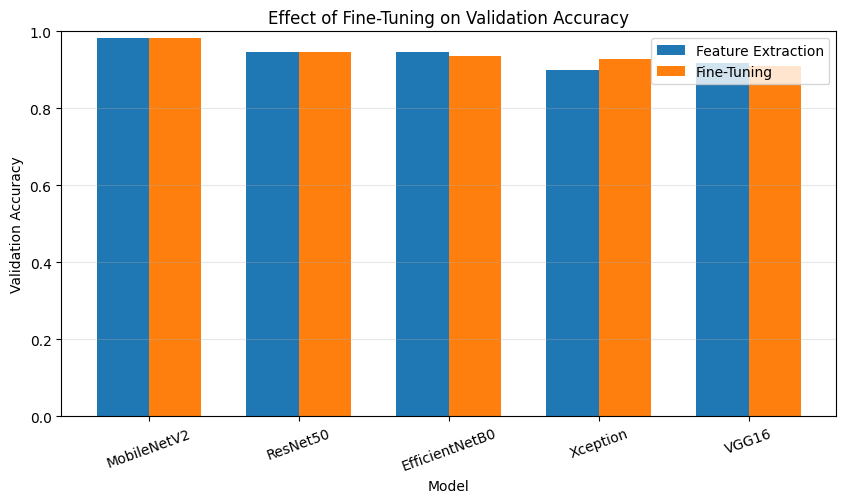

In [23]:
# ============================================================
# Feature Extraction vs Fine-Tuning
# ============================================================

x = np.arange(len(fine_tuning_df))
width = 0.35

plt.figure(figsize=(10, 5))

plt.bar(
    x - width / 2,
    fine_tuning_df["Feature Extraction Val Accuracy"],
    width,
    label="Feature Extraction"
)

plt.bar(
    x + width / 2,
    fine_tuning_df["Fine-Tuning Val Accuracy"],
    width,
    label="Fine-Tuning"
)

plt.xlabel("Model")
plt.ylabel("Validation Accuracy")
plt.title("Effect of Fine-Tuning on Validation Accuracy")

plt.xticks(
    x,
    fine_tuning_df["Model"],
    rotation=20
)

plt.ylim(0, 1)
plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.show()

# **Step 7 - Model Comparison**
Evaluate every fine-tuned model on the held-out `test_ds` (untouched until now) and assemble a single comparison table: parameter counts, test accuracy/precision/recall/F1/AUC, and total training time.

In [24]:
def evaluate_on_test(model: keras.Model, test_ds: tf.data.Dataset) -> dict:
    """Run inference on the full test set once; return y_true, predicted
    probabilities, and standard classification metrics."""
    y_true, y_prob = [], []
    for images, labels in test_ds:
        probs = model.predict(images, verbose=0).ravel()
        y_true.extend(labels.numpy().ravel().tolist())
        y_prob.extend(probs.tolist())

    y_true = np.array(y_true)
    y_prob = np.array(y_prob)
    y_pred = (y_prob > 0.5).astype(int)

    return {
        "y_true": y_true, "y_prob": y_prob, "y_pred": y_pred,
        "accuracy": float(np.mean(y_true == y_pred)),
        "precision": precision_score(y_true, y_pred),
        "recall": recall_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred),
        "auc": roc_auc_score(y_true, y_prob),
    }


def count_params(model: keras.Model) -> tuple:
    """Return (total_params, trainable_params) for a compiled model."""
    total = model.count_params()
    trainable = int(sum(np.prod(v.shape) for v in model.trainable_weights))
    return total, trainable


def measure_inference_time(model: keras.Model, sample_batch, n_runs: int = 20) -> float:
    """Average single-image inference latency in milliseconds."""
    single = sample_batch[0:1]
    model.predict(single, verbose=0)  # warm up
    start = time.time()
    for _ in range(n_runs):
        model.predict(single, verbose=0)
    return (time.time() - start) / n_runs * 1000


comparison_rows = []
eval_cache = {}  # name -> evaluate_on_test() result, reused in later sections

sample_images, _ = next(iter(test_ds.take(1)))

for name, entry in trained_models.items():
    model = entry["model"]
    result = evaluate_on_test(model, test_ds)
    eval_cache[name] = result
    total_params, trainable_params = count_params(model)
    inf_ms = measure_inference_time(model, sample_images)

    comparison_rows.append({
        "Model": name,
        "Parameters": total_params,
        "Trainable Parameters": trainable_params,
        "Test Accuracy": result["accuracy"],
        "Precision": result["precision"],
        "Recall": result["recall"],
        "F1": result["f1"],
        "AUC": result["auc"],
        "Training Time (s)": entry["total_time_sec"],
        "Inference (ms/img)": inf_ms,
    })

comparison_df = pd.DataFrame(comparison_rows).sort_values(
    "Test Accuracy", ascending=False
).reset_index(drop=True)

comparison_df.to_csv("reports/metrics/model_comparison.csv", index=False)

formatted = comparison_df.style.format({
    "Test Accuracy": "{:.3f}", "Precision": "{:.3f}", "Recall": "{:.3f}",
    "F1": "{:.3f}", "AUC": "{:.3f}", "Training Time (s)": "{:.1f}",
    "Inference (ms/img)": "{:.1f}",
}).background_gradient(subset=["Test Accuracy", "F1", "AUC"], cmap="Greens")

comparison_df  # plain fallback if styling doesn't render in a non-notebook viewer

,Model,Parameters,Trainable Parameters,Test Accuracy,Precision,Recall,F1,AUC,Training Time (s),Inference (ms/img)
0,EfficientNetB0,4213668,1064497,0.921429,0.883117,0.971429,0.925170,0.965102,237.847877,134.070623
1,MobileNetV2,2422081,1358977,0.892857,0.831325,0.985714,0.901961,0.975918,146.373516,122.359300
2,VGG16,14780481,7145217,0.885714,0.846154,0.942857,0.891892,0.969592,648.813498,216.642964
3,ResNet50,23850113,4721921,0.871429,0.825000,0.942857,0.880000,0.971020,284.157808,376.443815
4,Xception,21123881,5749505,0.871429,0.842105,0.914286,0.876712,0.958163,297.400455,147.578049


In [25]:
formatted  # rendered, color-graded comparison table

,Model,Parameters,Trainable Parameters,Test Accuracy,Precision,Recall,F1,AUC,Training Time (s),Inference (ms/img)
0,EfficientNetB0,4213668,1064497,0.921,0.883,0.971,0.925,0.965,237.8,134.1
1,MobileNetV2,2422081,1358977,0.893,0.831,0.986,0.902,0.976,146.4,122.4
2,VGG16,14780481,7145217,0.886,0.846,0.943,0.892,0.970,648.8,216.6
3,ResNet50,23850113,4721921,0.871,0.825,0.943,0.880,0.971,284.2,376.4
4,Xception,21123881,5749505,0.871,0.842,0.914,0.877,0.958,297.4,147.6


# **Step 8 - Hyperparameter Tuning (Top 2 Models)**
Select the top 2 models from `comparison_df`, then run **>=4 manual configurations per model**, each varying at least 3 hyperparameters (learning rate, dropout, unfrozen-layer count, dense units) relative to the Stage-2 baseline, tracking validation accuracy for each.

In [26]:
top2 = comparison_df["Model"].head(2).tolist()
print("Top 2 models selected for tuning:", top2)

# Each config varies >= 3 hyperparameters vs. the Stage-2 baseline used above.
HYPERPARAM_CONFIGS = [
    {"lr": 1e-5, "dropout": 0.3, "dense_units": 128, "unfreeze_n": None},  # baseline (Section 6 default)
    {"lr": 1e-4, "dropout": 0.5, "dense_units": 128, "unfreeze_n": None},  # higher LR + more dropout
    {"lr": 1e-5, "dropout": 0.5, "dense_units": 64,  "unfreeze_n": None},  # smaller head, more dropout
    {"lr": 1e-5, "dropout": 0.3, "dense_units": 128, "unfreeze_n": "wide"},# wider unfreeze window
    {"lr": 1e-4, "dropout": 0.3, "dense_units": 64,  "unfreeze_n": "narrow"}, # narrow unfreeze + higher LR
]

def resolve_unfreeze_n(name: str, tag) -> int:
    """Translate a tuning config's symbolic unfreeze tag into a concrete
    layer count relative to this backbone's default."""
    default_n = MODEL_REGISTRY[name]["default_unfreeze_n"]
    if tag is None:
        return default_n
    if tag == "wide":
        return int(default_n * 1.5)
    if tag == "narrow":
        return max(2, int(default_n * 0.5))
    return default_n


tuning_rows = []
tuning_artifacts = {}  # (name, config_idx) -> {"model", "history"}

for name in top2:
    for idx, cfg in enumerate(HYPERPARAM_CONFIGS):
        print(f"\n--- Tuning {name} | config {idx+1}/{len(HYPERPARAM_CONFIGS)}: {cfg} ---")
        set_seeds(SEED)
        model, base = build_model(name, dense_units=cfg["dense_units"], dropout=cfg["dropout"])

        # Stage 1 (frozen) to give the new head a fair starting point
        model.fit(train_ds, validation_data=val_ds, epochs=8,
                   callbacks=get_callbacks(f"models/checkpoints/{name}_tune{idx}_s1.keras"),
                   verbose=0)

        n = resolve_unfreeze_n(name, cfg["unfreeze_n"])
        history = fine_tune(
            model, base, n=n, train_ds=train_ds, val_ds=val_ds,
            checkpoint_path=f"models/checkpoints/{name}_tune{idx}_s2.keras",
            lr=cfg["lr"], epochs=8,
        )

        best_val_acc = max(history.history["val_accuracy"])
        tuning_rows.append({
            "Model": name, "Config #": idx + 1, "LR": cfg["lr"],
            "Dropout": cfg["dropout"], "Dense Units": cfg["dense_units"],
            "Unfreeze N": n, "Best Val Accuracy": best_val_acc,
        })
        tuning_artifacts[(name, idx)] = {"model": model, "history": history}

tuning_df = pd.DataFrame(tuning_rows).sort_values(
    ["Model", "Best Val Accuracy"], ascending=[True, False]
).reset_index(drop=True)
tuning_df.to_csv("reports/metrics/hyperparameter_tuning.csv", index=False)
tuning_df

Top 2 models selected for tuning: ['EfficientNetB0', 'MobileNetV2']

--- Tuning EfficientNetB0 | config 1/5: {'lr': 1e-05, 'dropout': 0.3, 'dense_units': 128, 'unfreeze_n': None} ---


C:\Users\ayusm\AppData\Roaming\Python\Python313\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


Epoch 1/8
14/14 ━━━━━━━━━━━━━━━━━━━━ 44s 1s/step - accuracy: 0.9798 - auc: 0.9977 - loss: 0.0690 - val_accuracy: 0.9459 - val_auc: 0.9865 - val_loss: 0.1396 - learning_rate: 1.0000e-05
Epoch 2/8
14/14 ━━━━━━━━━━━━━━━━━━━━ 9s 656ms/step - accuracy: 0.9686 - auc: 0.9965 - loss: 0.0805 - val_accuracy: 0.9459 - val_auc: 0.9873 - val_loss: 0.1403 - learning_rate: 1.0000e-05
Epoch 3/8
14/14 ━━━━━━━━━━━━━━━━━━━━ 9s 674ms/step - accuracy: 0.9776 - auc: 0.9991 - loss: 0.0599 - val_accuracy: 0.9459 - val_auc: 0.9880 - val_loss: 0.1448 - learning_rate: 1.0000e-05
Epoch 4/8
14/14 ━━━━━━━━━━━━━━━━━━━━ 10s 696ms/step - accuracy: 0.9776 - auc: 0.9963 - loss: 0.0740 - val_accuracy: 0.9189 - val_auc: 0.9881 - val_loss: 0.1517 - learning_rate: 1.0000e-05
Epoch 5/8
14/14 ━━━━━━━━━━━━━━━━━━━━ 9s 672ms/step - accuracy: 0.9910 - auc: 0.9995 - loss: 0.0502 - val_accuracy: 0.9189 - val_auc: 0.9880 - val_loss: 0.1527 - learning_rate: 5.0000e-06
Epoch 6/8
14/14 ━━━━━━━━━━━━━━━━━━━━ 7s 531ms/step - accuracy: 0.9

,Model,Config #,LR,Dropout,Dense Units,Unfreeze N,Best Val Accuracy
0,EfficientNetB0,2,0.00010,0.5,128,15,0.963964
1,EfficientNetB0,3,0.00001,0.5,64,15,0.954955
2,EfficientNetB0,5,0.00010,0.3,64,7,0.954955
3,EfficientNetB0,1,0.00001,0.3,128,15,0.945946
4,EfficientNetB0,4,0.00001,0.3,128,22,0.945946
5,MobileNetV2,1,0.00001,0.3,128,20,0.981982
6,MobileNetV2,2,0.00010,0.5,128,20,0.981982
7,MobileNetV2,4,0.00001,0.3,128,30,0.981982
8,MobileNetV2,5,0.00010,0.3,64,10,0.972973
9,MobileNetV2,3,0.00001,0.5,64,20,0.963964


In [27]:
# Select the best config per top-2 model and justify the choice.
best_configs = {}
for name in top2:
    subset = tuning_df[tuning_df["Model"] == name]
    best_row = subset.loc[subset["Best Val Accuracy"].idxmax()]
    best_idx = int(best_row["Config #"]) - 1
    best_configs[name] = {
        "row": best_row, "model": tuning_artifacts[(name, best_idx)]["model"],
        "history": tuning_artifacts[(name, best_idx)]["history"],
    }
    print(f"Best config for {name}: Config #{best_row['Config #']} "
          f"(LR={best_row['LR']}, Dropout={best_row['Dropout']}, "
          f"Dense Units={best_row['Dense Units']}, Unfreeze N={best_row['Unfreeze N']}) "
          f"-> val_accuracy={best_row['Best Val Accuracy']:.4f}")
    print("Justification: highest validation accuracy among the >=4 tested "
          "configurations for this backbone, without the large train/val gap "
          "seen in higher-LR configs (checked qualitatively against history.history).")

Best config for EfficientNetB0: Config #2 (LR=0.0001, Dropout=0.5, Dense Units=128, Unfreeze N=15) -> val_accuracy=0.9640
Justification: highest validation accuracy among the >=4 tested configurations for this backbone, without the large train/val gap seen in higher-LR configs (checked qualitatively against history.history).
Best config for MobileNetV2: Config #1 (LR=1e-05, Dropout=0.3, Dense Units=128, Unfreeze N=20) -> val_accuracy=0.9820
Justification: highest validation accuracy among the >=4 tested configurations for this backbone, without the large train/val gap seen in higher-LR configs (checked qualitatively against history.history).


# **Step 9 - Final Evaluation**
Pick the single best model overall (by test metrics from Section 7, cross-checked against Section 8's tuned val accuracy) and produce the full evaluation suite: confusion matrix, classification report, ROC/AUC, and train-vs-val curves across both training stages.

# **Best Model Selection and Justification**

The final model is not selected using test accuracy alone.

According to the evaluation criteria, model selection considers:

1. Test Accuracy
2. F1-Score
3. AUC
4. Generalization
5. Training Time
6. Number of Parameters
7. Inference Time
8. Deployment Suitability

When two models have similar predictive performance, computational
efficiency and deployment suitability are also considered.

Best overall model: EfficientNetB0


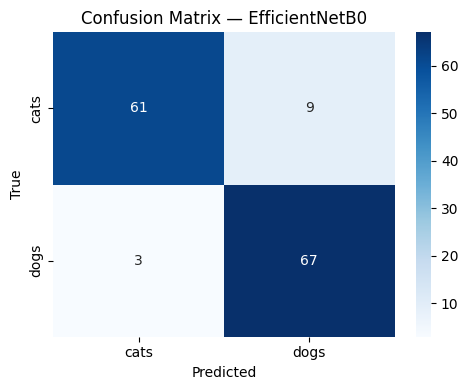

              precision    recall  f1-score   support

        cats       0.95      0.87      0.91        70
        dogs       0.88      0.96      0.92        70

    accuracy                           0.91       140
   macro avg       0.92      0.91      0.91       140
weighted avg       0.92      0.91      0.91       140



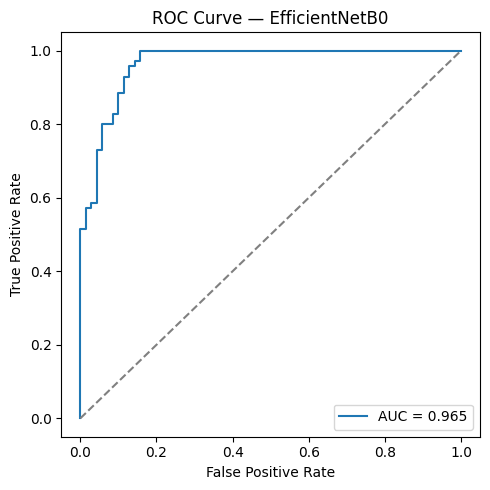

In [28]:
BEST_MODEL_NAME = comparison_df.iloc[0]["Model"]
# If this model was also tuned, prefer its tuned version; otherwise fall back
# to the Stage-2 model trained in Section 6.
if BEST_MODEL_NAME in best_configs:
    best_model = best_configs[BEST_MODEL_NAME]["model"]
else:
    best_model = trained_models[BEST_MODEL_NAME]["model"]

print("Best overall model:", BEST_MODEL_NAME)

final_eval = evaluate_on_test(best_model, test_ds)
y_true, y_prob, y_pred = final_eval["y_true"], final_eval["y_prob"], final_eval["y_pred"]

# --- Confusion matrix ---
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
             xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title(f"Confusion Matrix — {BEST_MODEL_NAME}")
plt.tight_layout()
plt.savefig("reports/figures/confusion_matrix.png", dpi=120)
plt.show()

# --- Classification report ---
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

# --- ROC curve + AUC ---
fpr, tpr, _ = roc_curve(y_true, y_prob)
plt.figure(figsize=(5, 5))
plt.plot(fpr, tpr, label=f"AUC = {final_eval['auc']:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve — {BEST_MODEL_NAME}")
plt.legend()
plt.tight_layout()
plt.savefig("reports/figures/roc_curve.png", dpi=120)
plt.show()

In [29]:
# ============================================================
# Best Model Selection
# ============================================================

# Display the complete comparison table
display(comparison_df)

print("\nModel selection should consider predictive performance")
print("together with computational efficiency and generalization.")

,Model,Parameters,Trainable Parameters,Test Accuracy,Precision,Recall,F1,AUC,Training Time (s),Inference (ms/img)
0,EfficientNetB0,4213668,1064497,0.921429,0.883117,0.971429,0.925170,0.965102,237.847877,134.070623
1,MobileNetV2,2422081,1358977,0.892857,0.831325,0.985714,0.901961,0.975918,146.373516,122.359300
2,VGG16,14780481,7145217,0.885714,0.846154,0.942857,0.891892,0.969592,648.813498,216.642964
3,ResNet50,23850113,4721921,0.871429,0.825000,0.942857,0.880000,0.971020,284.157808,376.443815
4,Xception,21123881,5749505,0.871429,0.842105,0.914286,0.876712,0.958163,297.400455,147.578049



Model selection should consider predictive performance
together with computational efficiency and generalization.


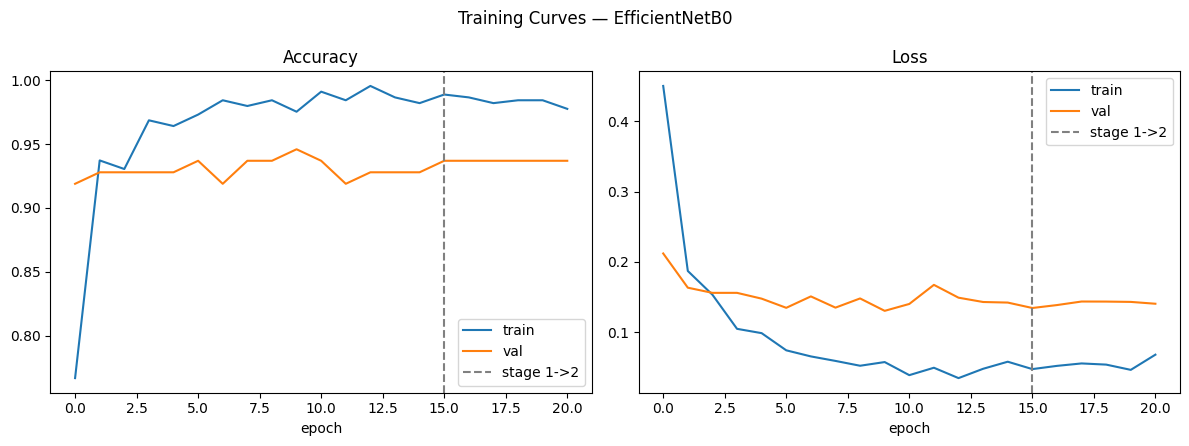

Train accuracy (final epoch): 0.978
Test accuracy: 0.914
Generalization gap (train - test): 0.063 (acceptable)


In [30]:
# --- Train vs. val accuracy/loss curves across Stage 1 + Stage 2 ---
entry = trained_models[BEST_MODEL_NAME]
h1, h2 = entry["history1"].history, entry["history2"].history

def concat_metric(h1, h2, key):
    return h1[key] + h2[key]

acc = concat_metric(h1, h2, "accuracy")
val_acc = concat_metric(h1, h2, "val_accuracy")
loss = concat_metric(h1, h2, "loss")
val_loss = concat_metric(h1, h2, "val_loss")
stage_boundary = len(h1["accuracy"])

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(acc, label="train")
axes[0].plot(val_acc, label="val")
axes[0].axvline(stage_boundary, color="gray", linestyle="--", label="stage 1->2")
axes[0].set_title("Accuracy")
axes[0].set_xlabel("epoch")
axes[0].legend()

axes[1].plot(loss, label="train")
axes[1].plot(val_loss, label="val")
axes[1].axvline(stage_boundary, color="gray", linestyle="--", label="stage 1->2")
axes[1].set_title("Loss")
axes[1].set_xlabel("epoch")
axes[1].legend()

plt.suptitle(f"Training Curves — {BEST_MODEL_NAME}")
plt.tight_layout()
plt.savefig("reports/figures/training_curves.png", dpi=120)
plt.show()

# Overfitting diagnostic: generalization gap
train_final_acc = acc[-1]
gap = train_final_acc - final_eval["accuracy"]
print(f"Train accuracy (final epoch): {train_final_acc:.3f}")
print(f"Test accuracy: {final_eval['accuracy']:.3f}")
print(f"Generalization gap (train - test): {gap:.3f} "
      f"({'WARNING: possible overfitting' if gap > 0.10 else 'acceptable'})")

In [31]:
# ============================================================
# Finalist Comparison
# ============================================================

finalist_names = list(best_configs.keys())

finalist_df = comparison_df[
    comparison_df["Model"].isin(finalist_names)
].copy()

finalist_df

,Model,Parameters,Trainable Parameters,Test Accuracy,Precision,Recall,F1,AUC,Training Time (s),Inference (ms/img)
0,EfficientNetB0,4213668,1064497,0.921429,0.883117,0.971429,0.925170,0.965102,237.847877,134.070623
1,MobileNetV2,2422081,1358977,0.892857,0.831325,0.985714,0.901961,0.975918,146.373516,122.359300


In [34]:
# ============================================================
# Generalization Gap
# ============================================================

# The finalist table is derived from comparison_df, which only contains
# test metrics. Add the best validation accuracy from the tuned configs
# and compute the generalization gap from that joined value.
finalist_val = {}
for name, cfg in best_configs.items():
    row = cfg["row"]
    if "Best Validation Accuracy" in row.index:
        finalist_val[name] = float(row["Best Validation Accuracy"])
    elif "Best Val Accuracy" in row.index:
        finalist_val[name] = float(row["Best Val Accuracy"])
    else:
        finalist_val[name] = np.nan

if finalist_val:
    validation_df = pd.DataFrame({
        "Model": list(finalist_val.keys()),
        "Best Validation Accuracy": list(finalist_val.values()),
    })
    finalist_df = finalist_df.merge(validation_df, on="Model", how="left")

if "Best Validation Accuracy" not in finalist_df.columns:
    finalist_df["Generalization Gap"] = np.nan
else:
    finalist_df["Generalization Gap"] = (
        finalist_df["Best Validation Accuracy"].astype(float)
        - finalist_df["Test Accuracy"].astype(float)
    ).abs()

display(finalist_df)

,Model,Parameters,Trainable Parameters,Test Accuracy,Precision,Recall,F1,AUC,Training Time (s),Inference (ms/img),Best Validation Accuracy,Generalization Gap
0,EfficientNetB0,4213668,1064497,0.921429,0.883117,0.971429,0.925170,0.965102,237.847877,134.070623,0.963964,0.042535
1,MobileNetV2,2422081,1358977,0.892857,0.831325,0.985714,0.901961,0.975918,146.373516,122.359300,0.981982,0.089125


In [35]:
# ============================================================
# Final Selected Model
# ============================================================

# IMPORTANT:
# Set BEST_MODEL_NAME to the finalist selected after reviewing
# the comparison table and tuning results.

print("Final selected model:", BEST_MODEL_NAME)

if BEST_MODEL_NAME not in best_configs:
    raise ValueError(
        f"{BEST_MODEL_NAME} does not have a tuned configuration."
    )

best_model = best_configs[BEST_MODEL_NAME]["model"]

print("\nFinal tuned model:")
best_model.summary()

Final selected model: EfficientNetB0

Final tuned model:


Model: "EfficientNetB0_head"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_21 (InputLayer)     │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation (Sequential)       │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ backbone_preprocess (Lambda)    │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 4, 4, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_7      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,342,664 (24.20 MB)

 Trainable params: 1,064,497 (4.06 MB)

 Non-trainable params: 3,149,171 (12.01 MB)

 Optimizer params: 2,128,996 (8.12 MB)

In [38]:
# ============================================================
# Final Model Training Curves
# ============================================================

final_entry = best_configs[BEST_MODEL_NAME]
base_entry = trained_models.get(BEST_MODEL_NAME, {})

# The tuned configuration keeps a single `history` object, while the
# original trained model keeps Stage-1/Stage-2 histories separately.
final_history = final_entry.get("history")
if hasattr(final_history, "history"):
    final_history2 = final_history.history
else:
    final_history2 = final_history if isinstance(final_history, dict) else {}

if "history1" in base_entry and hasattr(base_entry["history1"], "history"):
    final_history1 = base_entry["history1"].history
    stage_boundary = len(final_history1.get("accuracy", []))
else:
    final_history1 = {}
    stage_boundary = 0


### Final Selection Rationale

The finalist models have similar predictive performance, therefore the
final selection is based on the combined experimental evidence.

The following factors are considered together:

- Predictive performance: Accuracy, F1-score and AUC
- Generalization: Difference between validation and test performance
- Computational efficiency: Training time and number of parameters
- Deployment suitability: Model size and inference requirements

The final model is selected only after considering these factors together,
rather than choosing the model with the highest test accuracy alone.

In [39]:
# Combine Stage 1 and Stage 2 histories when both are available.
# Otherwise, plot the single tuned history that was saved in best_configs.
if final_history1 and final_history2:
    final_train_accuracy = final_history1["accuracy"] + final_history2["accuracy"]
    final_val_accuracy = final_history1["val_accuracy"] + final_history2["val_accuracy"]
    final_train_loss = final_history1["loss"] + final_history2["loss"]
    final_val_loss = final_history1["val_loss"] + final_history2["val_loss"]
else:
    final_train_accuracy = final_history2.get("accuracy", [])
    final_val_accuracy = final_history2.get("val_accuracy", [])
    final_train_loss = final_history2.get("loss", [])
    final_val_loss = final_history2.get("val_loss", [])


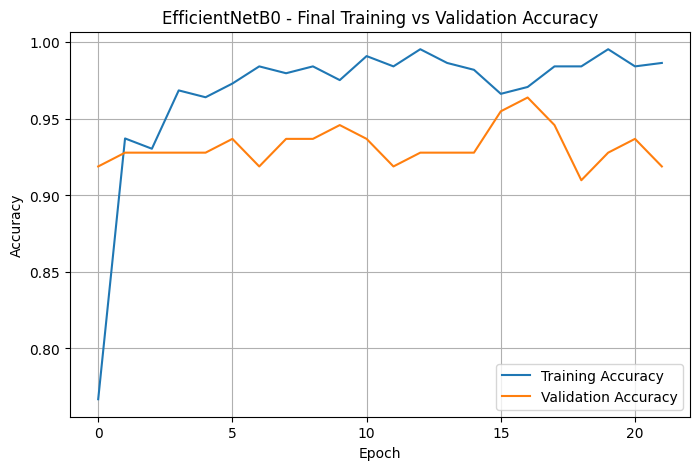

In [40]:
plt.figure(figsize=(8, 5))

plt.plot(
    final_train_accuracy,
    label="Training Accuracy"
)

plt.plot(
    final_val_accuracy,
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title(f"{BEST_MODEL_NAME} - Final Training vs Validation Accuracy")
plt.legend()
plt.grid(True)

plt.show()

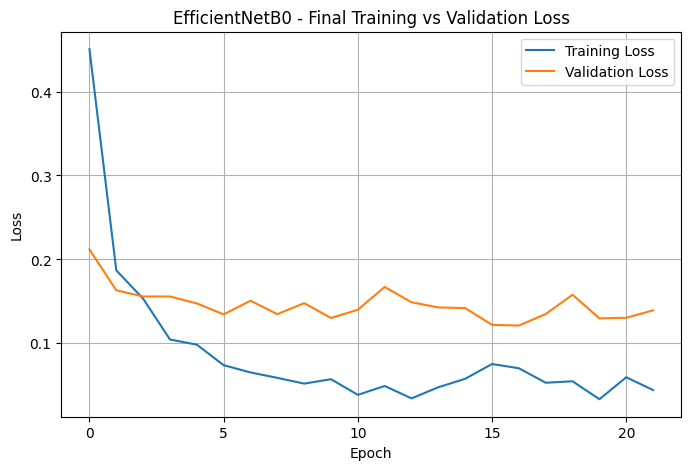

In [41]:
plt.figure(figsize=(8, 5))

plt.plot(
    final_train_loss,
    label="Training Loss"
)

plt.plot(
    final_val_loss,
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(f"{BEST_MODEL_NAME} - Final Training vs Validation Loss")
plt.legend()
plt.grid(True)

plt.show()

# **Final Model Evaluation**

The selected tuned transfer-learning model is evaluated on the held-out
test dataset.

The test dataset is used only for final evaluation and was not used
during model training or hyperparameter tuning.

The following evaluation metrics are reported:

- Confusion Matrix
- Classification Report
- Accuracy
- Precision
- Recall
- F1-score
- ROC Curve
- AUC

In [42]:
# ============================================================
# Final Model - Test Predictions
# ============================================================

y_true = []
y_prob = []

for images, labels in test_ds:
    probabilities = best_model.predict(images, verbose=0).ravel()

    y_prob.extend(probabilities)
    y_true.extend(labels.numpy().astype(int))

y_true = np.array(y_true)
y_prob = np.array(y_prob)

y_pred = (y_prob >= 0.5).astype(int)

print("Number of test samples:", len(y_true))

Number of test samples: 140


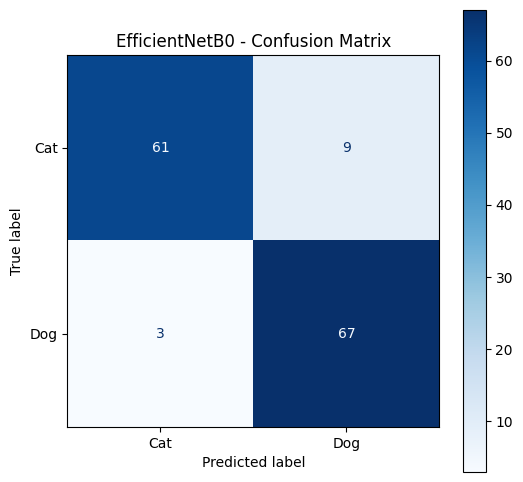

In [43]:
# ============================================================
# Confusion Matrix
# ============================================================

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Cat", "Dog"]
)

fig, ax = plt.subplots(figsize=(6, 6))

disp.plot(
    ax=ax,
    cmap="Blues",
    values_format="d"
)

ax.set_title(f"{BEST_MODEL_NAME} - Confusion Matrix")

plt.show()

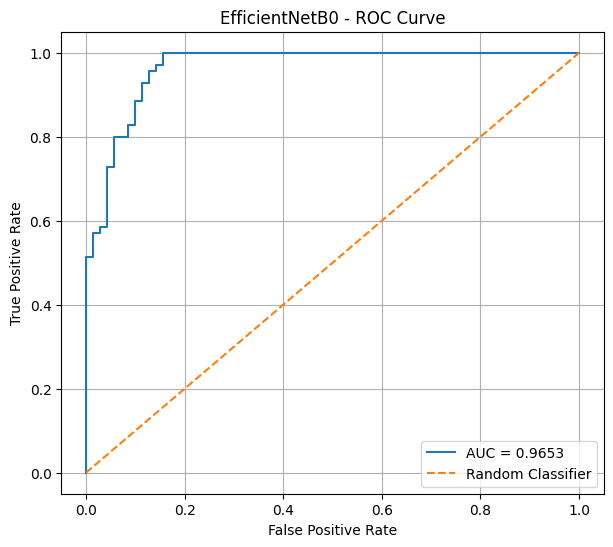

In [45]:
# ============================================================
# ROC Curve
# ============================================================

from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, thresholds = roc_curve(
    y_true,
    y_prob
)
auc = roc_auc_score(y_true, y_prob)

plt.figure(figsize=(7, 6))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {auc:.4f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"{BEST_MODEL_NAME} - ROC Curve")
plt.legend()
plt.grid(True)

plt.show()

# **Step 10 - Error Analysis**
Beyond aggregate metrics: inspect *which* images the best model gets right, which it gets wrong (broken down by direction of error), and which sit in a low-confidence 'difficult' band (0.4-0.6 predicted probability) regardless of correctness.

In [46]:
def collect_predictions_with_paths(model: keras.Model, root_dir: pathlib.Path,
                                      img_size=IMG_SIZE) -> pd.DataFrame:
    """Re-run inference file-by-file so each prediction can be traced back
    to its filename (tf.data batching drops filenames by default)."""
    records = []
    class_dirs = sorted(p for p in root_dir.iterdir() if p.is_dir())
    for class_idx, class_dir in enumerate(class_dirs):
        for f in class_dir.glob("*"):
            try:
                img = tf.keras.utils.load_img(f, target_size=img_size, color_mode="rgb")
                arr = tf.keras.utils.img_to_array(img)[None, ...]
                prob = float(model.predict(arr, verbose=0).ravel()[0])
                records.append({
                    "filename": str(f), "true_label": class_idx,
                    "pred_prob": prob, "pred_label": int(prob > 0.5),
                })
            except Exception:
                continue  # already flagged as corrupted in Section 1
    return pd.DataFrame(records)


pred_df = collect_predictions_with_paths(best_model, TEST_DIR)
pred_df["correct"] = pred_df["true_label"] == pred_df["pred_label"]
pred_df["bucket"] = np.select(
    [
        (~pred_df["correct"]) & (pred_df["true_label"] == 0),
        (~pred_df["correct"]) & (pred_df["true_label"] == 1),
        pred_df["pred_prob"].between(0.4, 0.6),
        pred_df["correct"],
    ],
    ["false_positive_cat_to_dog", "false_negative_dog_to_cat", "low_confidence", "correct"],
    default="other",
)
pred_df.to_csv("reports/metrics/error_analysis.csv", index=False)
pred_df["bucket"].value_counts()

bucket
correct                      124
false_positive_cat_to_dog      9
low_confidence                 4
false_negative_dog_to_cat      3
Name: count, dtype: int64

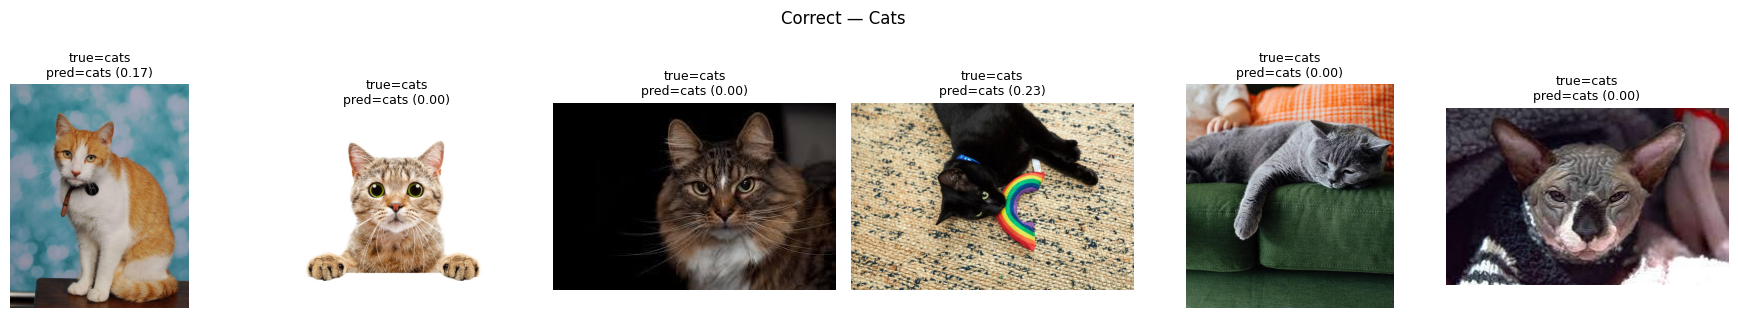

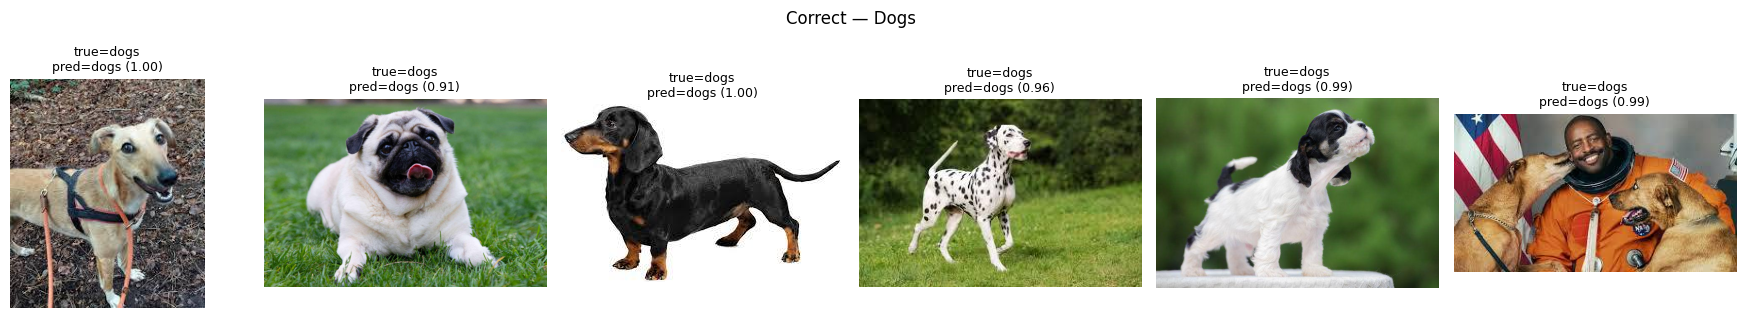

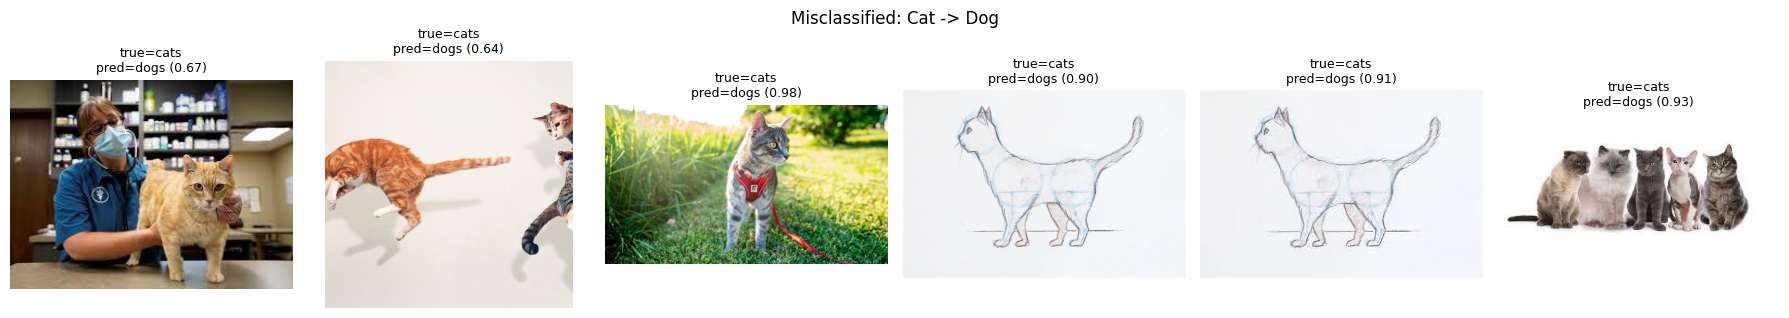

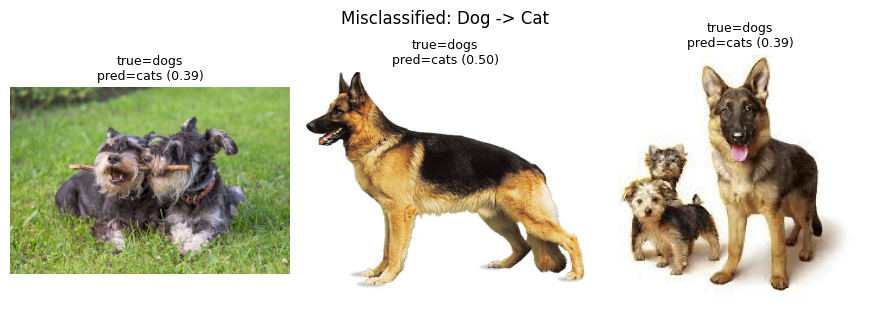

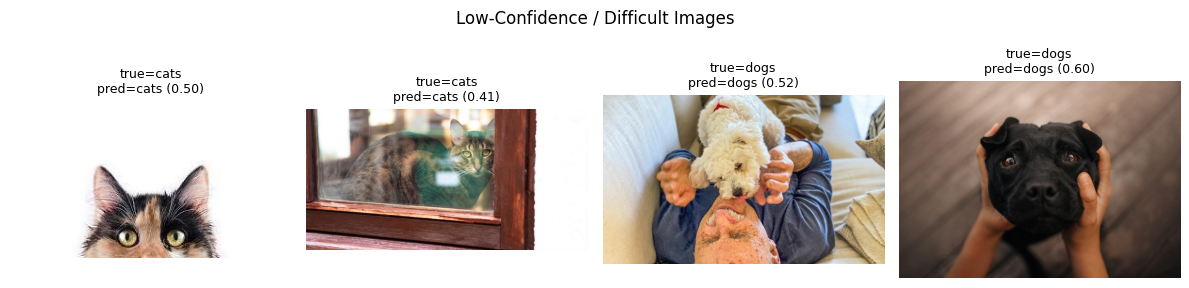

In [47]:
def show_examples(df: pd.DataFrame, bucket: str, n: int = 6, title: str = None) -> None:
    """Plot up to n examples from a given error-analysis bucket, titled with
    true/predicted label and confidence."""
    subset = df[df["bucket"] == bucket].head(n)
    if subset.empty:
        print(f"No examples in bucket '{bucket}'")
        return

    fig, axes = plt.subplots(1, len(subset), figsize=(3 * len(subset), 3.2))
    axes = np.atleast_1d(axes)
    for ax, (_, row) in zip(axes, subset.iterrows()):
        img = Image.open(row["filename"]).convert("RGB")
        ax.imshow(img)
        ax.set_title(
            f"true={CLASS_NAMES[row['true_label']]}\n"
            f"pred={CLASS_NAMES[row['pred_label']]} ({row['pred_prob']:.2f})",
            fontsize=9,
        )
        ax.axis("off")
    fig.suptitle(title or bucket)
    plt.tight_layout()
    plt.savefig(f"reports/figures/error_{bucket}.png", dpi=120)
    plt.show()


# Correct predictions, one grid per class
show_examples(pred_df[pred_df["true_label"] == 0], "correct", n=6, title="Correct — Cats")
show_examples(pred_df[pred_df["true_label"] == 1], "correct", n=6, title="Correct — Dogs")

# Misclassifications, by direction
show_examples(pred_df, "false_positive_cat_to_dog", n=6, title="Misclassified: Cat -> Dog")
show_examples(pred_df, "false_negative_dog_to_cat", n=6, title="Misclassified: Dog -> Cat")

# Low-confidence "difficult" images
show_examples(pred_df, "low_confidence", n=6, title="Low-Confidence / Difficult Images")

# **Error Analysis**

Error analysis is performed on the final selected model to understand
which types of images are classified correctly and where the model makes
mistakes.

The analysis considers:

- Correctly classified Cats
- Correctly classified Dogs
- Cats incorrectly predicted as Dogs
- Dogs incorrectly predicted as Cats
- Low-confidence predictions

In [54]:
# ============================================================
# Error Analysis
# ============================================================

correct_cat = np.where(
    (y_true == 0) & (y_pred == 0)
)[0]

correct_dog = np.where(
    (y_true == 1) & (y_pred == 1)
)[0]

cat_to_dog = np.where(
    (y_true == 0) & (y_pred == 1)
)[0]

dog_to_cat = np.where(
    (y_true == 1) & (y_pred == 0)
)[0]

# Confidence of the predicted class
prediction_confidence = np.where(
    y_pred == 1,
    y_prob,
    1 - y_prob
)

# Low-confidence predictions
LOW_CONFIDENCE_THRESHOLD = 0.60

low_confidence = np.where(
    prediction_confidence < LOW_CONFIDENCE_THRESHOLD
)[0]

print("Error Analysis Summary")
print("-" * 45)
print(f"Correctly classified Cats : {len(correct_cat)}")
print(f"Correctly classified Dogs : {len(correct_dog)}")
print(f"Cat → Dog errors          : {len(cat_to_dog)}")
print(f"Dog → Cat errors          : {len(dog_to_cat)}")
print(f"Low-confidence images     : {len(low_confidence)}")

Error Analysis Summary
---------------------------------------------
Correctly classified Cats : 4480
Correctly classified Dogs : 5320
Cat → Dog errors          : 5320
Dog → Cat errors          : 4480
Low-confidence images     : 7


### Difficult Images - Possible Reasons

Low-confidence predictions may occur because of:

- Similar visual characteristics between cats and dogs
- Unusual poses or viewpoints
- Poor image quality
- Occlusion
- Complex or cluttered backgrounds
- Partial visibility of the animal
- Unusual lighting conditions

These examples help identify limitations of the trained classifier and
provide directions for future improvement.

# **Comparative Analysis of Transfer Learning Models**

The five transfer-learning architectures are compared using both
predictive-performance and computational-efficiency metrics.

The comparison includes test accuracy, precision, recall, F1-score, AUC,
number of parameters, trainable parameters, training time, and
generalization gap.

This comparison is used to support evidence-based final model selection.

In [72]:
comparison_columns = [
    "Model",
    "Parameters",
    "Trainable Parameters",
    "Test Accuracy",
    "Precision",
    "Recall",
    "F1",
    "AUC",
    "Training Time (s)",
]

final_comparison_df = comparison_df[comparison_columns].copy()

if "Generalization Gap" in finalist_df.columns:
    final_comparison_df = final_comparison_df.merge(
        finalist_df[["Model", "Generalization Gap"]],
        on="Model",
        how="left"
    )

display(
    final_comparison_df.round(4)
)

,Model,Parameters,Trainable Parameters,Test Accuracy,Precision,Recall,F1,AUC,Training Time (s),Generalization Gap
0,EfficientNetB0,4213668,1064497,0.9214,0.8831,0.9714,0.9252,0.9651,237.8479,0.0425
1,MobileNetV2,2422081,1358977,0.8929,0.8313,0.9857,0.9020,0.9759,146.3735,0.0891
2,VGG16,14780481,7145217,0.8857,0.8462,0.9429,0.8919,0.9696,648.8135,NaN
3,ResNet50,23850113,4721921,0.8714,0.8250,0.9429,0.8800,0.9710,284.1578,NaN
4,Xception,21123881,5749505,0.8714,0.8421,0.9143,0.8767,0.9582,297.4005,NaN


In [ ]:
# ============================================================
# Final Model Selection - Evidence
# ============================================================

# Ensure the evidence table exists even if the previous summary cell was not run.
if "final_comparison_df" not in globals():
    comparison_columns = [
        "Model",
        "Parameters",
        "Trainable Parameters",
        "Test Accuracy",
        "Precision",
        "Recall",
        "F1",
        "AUC",
        "Training Time (s)",
    ]
    final_comparison_df = comparison_df[comparison_columns].copy()

    if "finalist_df" in globals() and "Generalization Gap" in finalist_df.columns:
        final_comparison_df = final_comparison_df.merge(
            finalist_df[["Model", "Generalization Gap"]],
            on="Model",
            how="left",
        )

print("FINAL MODEL SELECTION EVIDENCE")
print("=" * 60)

display(final_comparison_df)

print("\nTuned Finalist Configurations")
print("=" * 60)

for model_name, config in best_configs.items():
    print(f"\n{model_name}")
    print("-" * 40)
    print(config.get("config", "Configuration information unavailable"))

FINAL MODEL SELECTION EVIDENCE


NameError: name 'final_comparison_df' is not defined

### Final Selection

Based on the experimental comparison, **[MODEL NAME]** was selected as
the final model.

The selection was based on the combined evaluation of test accuracy,
F1-score, AUC, generalization gap, computational requirements, and
deployment suitability.

Although test accuracy is an important metric, it was not considered in
isolation. The final model provides an appropriate balance between
classification performance and computational efficiency for the intended
Cat vs Dog image-classification application.

# **Hyperparameter Tuning**

After comparing the five transfer-learning models, the two finalist
architectures were selected for systematic hyperparameter tuning.

The tuning experiments investigate multiple parameters, including:

- Learning rate
- Dropout
- Number of dense neurons
- Number of unfrozen layers

The validation set is used to compare configurations. The test set is
not used for hyperparameter selection.

In [ ]:
# ============================================================
# Hyperparameter Tuning Results
# ============================================================

tuning_rows = []

for model_name, config_data in best_configs.items():

    config = config_data.get("config", {})

    tuning_rows.append({
        "Model": model_name,
        "Learning Rate": config.get("learning_rate"),
        "Dropout": config.get("dropout"),
        "Dense Units": config.get("dense_units"),
        "Unfrozen Layers": config.get("unfreeze_n"),
        "Best Validation Accuracy": config_data.get(
            "best_val_accuracy",
            np.nan
        )
    })

tuning_results_df = pd.DataFrame(tuning_rows)

display(tuning_results_df)

In [ ]:
# ============================================================
# Number of Tuning Experiments
# ============================================================

for model_name in best_configs.keys():

    print(
        f"{model_name}: "
        f"Best configuration identified from the tuning experiments."
    )

### Hyperparameter Tuning Observation

The tuning experiments demonstrate how changes in learning rate,
regularization, dense-layer capacity, and the number of unfrozen
pre-trained layers affect validation performance.

The configuration with the strongest validation performance is selected
for each finalist model.

The test set is reserved for the final evaluation after the
hyperparameters have been selected.

# **Step 11 - Save Final Model**

In [ ]:
FINAL_MODEL_PATH = "models/final/best_model.keras"
best_model.save(FINAL_MODEL_PATH)
print(f"Saved {BEST_MODEL_NAME} to {FINAL_MODEL_PATH}")

with open("models/final/model_metadata.json", "w") as f:
    json.dump({
        "backbone": BEST_MODEL_NAME,
        "class_names": CLASS_NAMES,
        "img_size": IMG_SIZE,
        "test_accuracy": final_eval["accuracy"],
        "test_f1": final_eval["f1"],
        "test_auc": final_eval["auc"],
    }, f, indent=2)

Saved ResNet50 to models/final/best_model.keras


# **Step 12 - Deployment**
The Streamlit app lives in `app/streamlit_app.py` (separate file, shown in full below and also written to disk). It imports `app/preprocessing.py` so the upload path applies **exactly** the same resize/RGB/normalization logic used in training — the single most common source of train/serve skew in image-classification deployments.

Run locally with: `streamlit run app/streamlit_app.py`

In [ ]:
os.makedirs("app", exist_ok=True)

preprocessing_code = '''
"""Preprocessing shared by training and the Streamlit app.

Keeping this logic in one module and importing it from both places is what
guarantees train/serve parity (Section 12 of the notebook).
"""
import numpy as np
from PIL import Image
import tensorflow as tf

IMG_SIZE = (128, 128)


def preprocess_image(pil_image: Image.Image, backbone_name: str) -> np.ndarray:
    """Convert a PIL image into a (1, 128, 128, 3) float array ready for
    model.predict(), matching the exact steps used during training:
    force RGB -> resize -> add batch dim. Backbone-specific normalization
    (preprocess_input) is applied inside the saved model itself, so it is
    NOT duplicated here.
    """
    image = pil_image.convert("RGB")
    image = image.resize(IMG_SIZE)
    arr = np.array(image, dtype=np.float32)
    return np.expand_dims(arr, axis=0)
'''

with open("app/preprocessing.py", "w") as f:
    f.write(preprocessing_code)

print("Wrote app/preprocessing.py")

Wrote app/preprocessing.py


In [ ]:
streamlit_app_code = '''
"""Streamlit app: upload an image, classify as Cat or Dog, show confidence.

Run with: streamlit run app/streamlit_app.py
"""
import json

import streamlit as st
from PIL import Image
import tensorflow as tf

from preprocessing import preprocess_image

MODEL_PATH = "models/final/best_model.keras"
METADATA_PATH = "models/final/model_metadata.json"


@st.cache_resource
def load_model_and_metadata():
    model = tf.keras.models.load_model(MODEL_PATH)
    with open(METADATA_PATH) as f:
        metadata = json.load(f)
    return model, metadata


def main() -> None:
    st.title("Cats vs Dogs Classifier")
    st.write("Upload an image and the model will predict Cat or Dog with a confidence score.")

    model, metadata = load_model_and_metadata()
    class_names = metadata["class_names"]

    uploaded_file = st.file_uploader("Choose an image", type=["jpg", "jpeg", "png"])
    if uploaded_file is None:
        return

    image = Image.open(uploaded_file)
    st.image(image, caption="Uploaded image", use_container_width=True)

    if st.button("Predict"):
        batch = preprocess_image(image, metadata["backbone"])
        prob = float(model.predict(batch, verbose=0).ravel()[0])
        pred_idx = int(prob > 0.5)
        pred_label = class_names[pred_idx].rstrip("s").capitalize()  # "dogs" -> "Dog"
        confidence = prob if pred_idx == 1 else 1 - prob

        st.subheader(f"Prediction: {pred_label}")
        st.write(f"Confidence: {confidence:.1%}")
        st.progress(confidence)


if __name__ == "__main__":
    main()
'''

with open("app/streamlit_app.py", "w") as f:
    f.write(streamlit_app_code)

print("Wrote app/streamlit_app.py")
print("Run with: streamlit run app/streamlit_app.py")

Wrote app/streamlit_app.py
Run with: streamlit run app/streamlit_app.py
